# Day 23: In-Class Assignment

___


### <p style="text-align: right;"> &#9989;&nbsp; **Put your name here** </p>
#### <p style="text-align: right;"> &#9989;&nbsp; Put your group member names here</p>

## Massaging a mouse's brain

<img src="https://raw.githubusercontent.com/ejamezquita/plnt_sci2500/refs/heads/main/images/lymphatic_system_csf_neuroscience.jpg" style="display:block; margin-left: auto; margin-right: auto; width: 55%" alt="Scheme outlining the CSF outflow routes to the mandibular lymph nodes. Green: lymphatic vessels with black arrows indicating direction of flow, red: facial arteries.">
<p style="font-size:0.85em; text-align: center;">Credits: <a href="https://neurosciencenews.com/lymphatic-system-cranial-cavity-7912/" target="_blank">Ma et al (2017)</a></p>

### Learning goals of today's assignment

* Compute and plot confidence bands for allometry models
* Use the linear model to estimate the weight of the diplodocus and estimate its confidence interval

## Assignment instructions

Work with your group to complete this assignment. Instructions for submitting this assignment are at the end of the Notebook. The assignment is due at the end of class.

___

## Importing the modules that we will need

Before we start anything, it is good practice to have all our imports as the first Python cell.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats

Also load the [SciKit Post Hoc](https://scikit-posthocs.readthedocs.io/en/latest/intro.html) module.

In [2]:
# import

---

## 1. Picking mice brains and their cerebrospinal fluid (CSF)

This paper demonstrates that knowingly stimulating the lymphatics under skin on the neck and face can significantly enhance the flow of cerebrospinal fluid (CSF)&mdash;the liquid that cushions the brain and helps remove toxic waste&mdash;through lymphatic vessels. This offers a new approach to clearing brain waste using safe, non-invasive mechanical stimulation, rather than relying on drugs or surgical interventions. (Summary from [MedicalXpress](https://medicalxpress.com/news/2025-06-invasive-mechanical-brain-clearance.html))

> Jin, H., Yoon, JH., Hong, S.P. et al. (2025) [Increased CSF drainage by non-invasive manipulation of cervical lymphatics](https://doi.org/10.1038/s41586-025-09052-5). *Nature* **643**, 755&ndash;767

<img src="https://raw.githubusercontent.com/ejamezquita/plnt_sci2500/refs/heads/main/images/jin_etal_2025_f6.png" style="display:block; margin-left: auto; margin-right: auto; width: 65%" alt="Increased CSF drainage by non-invasive mechanical stimulation of scLVs.">
<p style="font-size:0.85em; text-align: center;">Credits: <a href="https://doi.org/10.1038/s41586-025-09052-5" target="_blank">Jin et al (2025)</a></p>

&#9989;&nbsp;  **Question 1**

- What information do you get from the jitterplots of Figure c? Do you think it matches the actual observations of Figure b?

<font size=6 color="#009600">&#9998;</font> *Put your answer here*

### 1.1 Data loading and visualization

&#9989;&nbsp;  **Task 1**

- Load the "**TMR concentration and drainage**" sheet from the `'41587_2025_9052_MOESM8_ESM.xlsx'` file (attached in Canvas).
- Remember [that `read_excel` has](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.read_excel.html) a `sheet_name` parameter.
- Display its first few rows. You should have 11 rows and 15 columns.
- Do you notice something unusual in how the data is formated?

In [3]:
# Load with pandas

### 1.1 DataFrame melting&mdash;going from wide to long format

This DataFrame is a bit unusual: the columns 1&ndash;9 do not correspond to different traits measured but they correspond to different mice. Normally, different mice would go in different rows, not different columns. We could transpose&mdash;make the columns into rows and viceversa&mdash;but that would put the metadata (e.g. "Group") in rows.

Instead, we can *melt* the DataFrame so it goes from a *wide* to a *long* format.

- Right now we have a *wide* format: a single row has multiple measurements (alongside a bunch of metadata)
- We need a *long* format: each row has a single value (alongside the same metadata.)

&#9989;&nbsp;  **Task 2**

Use [the `.melt` function](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.melt.html) to make the DataFrame a long format one. Things to keep in mind:
- `id_vars`: What columns has metadata?
- `value_vars`: What columns have actual measurements? Notice that "If not specified, uses all columns that are not set as `id_vars`."

You should have a DataFrame with a single measurement per row.

[Future reference and more info](https://pandas.pydata.org/pandas-docs/stable/user_guide/reshaping.html#melt-and-wide-to-long).

In [4]:
# melted dataframe


&#9989;&nbsp;  **Task 3**

- [Use `.dropna` to](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.dropna.html) drop all the rows with NaN measurements.

In [5]:
# remove nans

### 1.2 Q-Q plots

&#9989;&nbsp;  **Task 4**

The bread-and-butter of every data analysis: Q-Q plots to check for normality. Let's plot all of them at the same time: all three regions and three treatments. Nine Q-Q plots in total.

- Below is a skeleton of the plot: notice how everything boils down to an inner loop
- We have lists for the regions and treatments of interest
- Label axes/titles where appropriate to keep track of what Q-Q is of what.

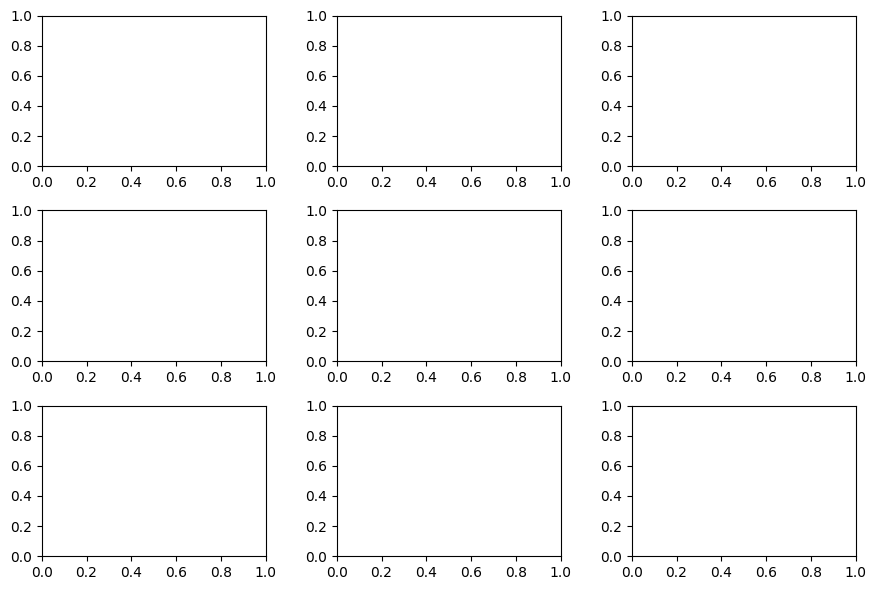

In [6]:
areas = ['scLV', 'smLN (stimulated)', 'smLN (contralateral)']
groups = ['Sham', 'Low', 'High']

quantiles = np.linspace( 0.1, 0.9, 7)
fig, ax = plt.subplots(len(groups), len(areas), figsize=(3*len(areas),2*len(groups)))
for i in range(len(areas)):
    for j in range(len(groups)):

        pass
        # y = Series with the values of areas[j] and groups[i]

        # dataq = quantiles of y
        # normq = quantiles of a normal distribution with loc = mean(y) and scale = SD(y)

        # draw identity line
        # axline xy1 = ( dataq[0], dataq[0] ) and slope = 1

        # draw Q-Q (scatter) plot normq vs dataq

fig.tight_layout()

&#9989;&nbsp;  **Question 5**

In general, when looking at a set of measurements&mdash;like the nine above&mdash;it is good to compare them with the same test.

- Based on the Q-Q plots, would you compare each set of treatments with Games-Howell or Dunn's test (normality vs non-normality requirements)?

<font size=6 color="#009600">&#9998;</font> *Put your answer here*

In [7]:
# Your linear model
# Print the intercept, slope, and R2

### 1.3 Jitterplots and confidence intervals

Before jumping into stats and p-chasing, we must make sure that we have a baseline understanding of the data.

&#9989;&nbsp; **Task 6**

- Below is a skeleton of the jitterplots for all three areas and treatments (three treatments per plot): notice how everything boils down to an inner loop
- We also plot the mean for every sample along its 95% confidence interval.
- We re-use the lists for the regions and treatments of interest
- Label axes/titles/ticks where appropriate to keep track of which jitter is of which.

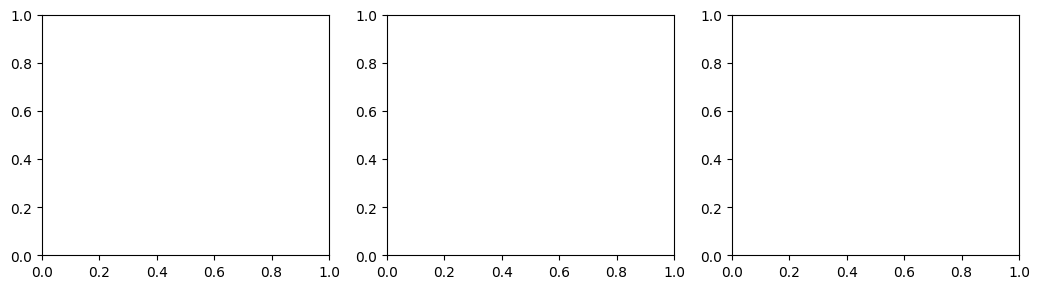

In [8]:
# Complete the code

nudge = np.random.default_rng(42).uniform(-0.15, 0.15, 100)

fig, ax = plt.subplots(1, len(areas), figsize=(3.5*len(areas),3))
for i in range(len(areas)):
    for j in range(len(groups)):
        pass
        # y = (Series with the values of areas[j] and groups[i])/1000

        # 95% Confidence interval of the mean for y
        # ci = t(0.975, length of y - 1) * SE(y)

        # jitterplot ( i + nudge, y)

        # errorbar( i, mean(y), y errors = ci)

fig.tight_layout();

Remember the rule of thumb: when looking at 95% confidence intervals, if these overlap a lot, then the p-value should be large; if there is no overlap, the p-value should be small; if there is *some* overlap, things can go either way.

&#9989;&nbsp;  **Question 7**

- Based on the jitterplots and CIs, which treatment comparisons do you expect to have small p-values when looking at the stimulated smLN?
- Which treatment comparisons do you expect to have high p-values when looking at the contralateral smLN?

<font size=6 color="#009600">&#9998;</font> *Put your answer here.*


---

## 2. Multiple-sample comparison tests

&#9989;&nbsp;  **Task 8**

Let's focus just on the samples from the stimulated smLN for now.

- Put your three samples&mdash;sham, low, and high&mdash;in a list.

In [9]:
# Your code

### 2.1 Games-Howell

&#9989;&nbsp; **Task 9**

Looking back at the Q-Q plots from T4, most of them look normal-ish. So we'll go with a Games-Howell multiple sample test.

- Compute and display the p-values corresponding to a Games-Howell test
- Make sure that your p-value matrix is a DataFrame instead, with informative index and column names.
- Do the p-values match your intuition from Q7?

In [10]:
# Your code

### 2.2 Tamhane's $T_2$

&#9989;&nbsp; **Task 10**

In the pre-class, we mentioned that Games-Howell is just *one* of many post-hoc tests that can be used with normal-ish data. Another such test is Tamhane's $T_2$. This one is not available in SciPy's `stats` but it is available in `scikit_posthocs` as [the `.posthoc_tamhane` function](https://scikit-posthocs.readthedocs.io/en/latest/generated/scikit_posthocs.posthoc_tamhane.html)

- Compute and display the p-values corresponding to Tamhane's $T_2$ test
- Are they *truly* different from those from Games-Howell?

In [11]:
# Your code

### 2.3 So what test should I use?

Short answer: Games-Howell and Tamhane's $T_2$ are very comparable. I personally am not familiar with the nitty-gritty behind their math, so I cannot tell you which one should be favored when. Both are good choices for normal-ish samples. While these two will not produce the exact same p-values, these will be pretty close to each other as you just saw.

Ultimately, whichever p-values you get, these are only meaningful if they coincide with your data visualization and your domain knowledge.

**Remember**: The important bit is to consider if a p-value is smaller or larger than a set significance threshold. Its *actual* value is secondary. On that regard, use whichever test you think is easier to use in Python.

---

## Congratulations, you're done!

Submit this assignment by uploading it to the course Canvas web page.  Go to the "In-class assignments" folder, find the appropriate submission link, and upload it there.

See you next class!

&#169; Copyright 2026,  Division of Plant Science & Technology&mdash;University of Missouri